# Data Preparation for Machine Learning

This notebook prepares the engineered dataset for machine learning by selecting relevant features, checking class balance, encoding categorical variables, scaling numerical variables, and constructing a preprocessing pipeline.

The objectives of this notebook are:

- Select the final predictor variables.
- Separate the features from the target variable.
- Evaluate the balance of the target classes.
- Split the data into training and testing sets.
- Apply preprocessing techniques including encoding and scaling.
- Build a reusable preprocessing pipeline that can be used consistently during model training and deployment.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    TargetEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

pd.set_option("display.max_columns", None)

In [2]:
from pathlib import Path


def find_project_root() -> Path:
    """
    Locate the project root whether the notebook is launched
    from the project root or from inside the notebooks folder.
    """
    current_path = Path.cwd().resolve()

    for candidate in [current_path, *current_path.parents]:
        if (
            (candidate / "notebooks").is_dir()
            and (candidate / "requirements.txt").is_file()
        ):
            return candidate

    raise FileNotFoundError(
        "Project root could not be located. "
        "Run this notebook from inside the "
        "Flight_Delay_Prediction project folder."
    )


PROJECT_ROOT = find_project_root()

RAW_DATA_DIRECTORY = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIRECTORY = PROJECT_ROOT / "data" / "processed"
MODELS_DIRECTORY = PROJECT_ROOT / "models"

RAW_DATA_DIRECTORY.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIRECTORY.mkdir(parents=True, exist_ok=True)
MODELS_DIRECTORY.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)

Project root: /Users/omarzakzook/Desktop/Flight_Delay_Prediction


In [3]:
engineered_data_path = (
    PROCESSED_DATA_DIRECTORY
    / "engineered_flight_data.csv"
)

df = pd.read_csv(
    engineered_data_path,
    parse_dates=["FL_DATE"]
)

print("Loaded from:", engineered_data_path)
print("Dataset shape:", df.shape)

df.head()

Loaded from: /Users/omarzakzook/Desktop/Flight_Delay_Prediction/data/processed/engineered_flight_data.csv
Dataset shape: (2913802, 30)


,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,CRS_ARR_TIME,CRS_ELAPSED_TIME,DISTANCE,IS_DELAYED,YEAR,MONTH,DAY,DAY_OF_WEEK,QUARTER,IS_WEEKEND,DEP_HOUR,TIME_OF_DAY,SEASON,DISTANCE_CATEGORY,ROUTE,IS_PEAK_SEASON,IS_BUSY_HOUR
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",1155,1151.0,-4.0,1501,186.0,1065.0,0,2019,1,9,Wednesday,1,0,11,Morning,Winter,Medium,FLL_EWR,0,0
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",2120,2114.0,-6.0,2315,235.0,1399.0,0,2022,11,19,Saturday,4,1,21,Night,Autumn,Medium,MSP_SEA,1,0
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",954,1000.0,6.0,1252,118.0,680.0,0,2022,7,22,Friday,3,0,9,Morning,Summer,Medium,DEN_MSP,1,1
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",1609,1608.0,-1.0,1829,260.0,1589.0,1,2023,3,6,Monday,1,0,16,Afternoon,Spring,Long,MSP_SFO,0,1
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",1840,1838.0,-2.0,2041,181.0,985.0,0,2020,2,23,Sunday,1,1,18,Evening,Winter,Medium,MCO_DFW,0,1


### Interpretation

The engineered dataset has been successfully loaded. This dataset contains the cleaned observations, engineered features, and the target variable required for machine learning.

In [4]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 2913802
Columns : 30


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2913802 entries, 0 to 2913801
Data columns (total 30 columns):
 #   Column             Dtype         
---  ------             -----         
 0   FL_DATE            datetime64[ns]
 1   AIRLINE            object        
 2   AIRLINE_DOT        object        
 3   AIRLINE_CODE       object        
 4   DOT_CODE           int64         
 5   FL_NUMBER          int64         
 6   ORIGIN             object        
 7   ORIGIN_CITY        object        
 8   DEST               object        
 9   DEST_CITY          object        
 10  CRS_DEP_TIME       int64         
 11  DEP_TIME           float64       
 12  DEP_DELAY          float64       
 13  CRS_ARR_TIME       int64         
 14  CRS_ELAPSED_TIME   float64       
 15  DISTANCE           float64       
 16  IS_DELAYED         int64         
 17  YEAR               int64         
 18  MONTH              int64         
 19  DAY                int64         
 20  DAY_OF_WEEK        objec

# Training-Period Class Balance Analysis

Class balance is examined using only the 2019–2021 training period.

The 2022 validation labels and 2023 holdout labels are not used in this analysis. This prevents information from future evaluation periods from influencing model-development decisions.

In [6]:
training_target = df.loc[
    df["YEAR"] <= 2021,
    "IS_DELAYED"
]

class_counts = (
    training_target
    .value_counts()
    .sort_index()
)

class_percentages = (
    training_target
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

balance_df = pd.DataFrame({
    "Count": class_counts,
    "Percentage (%)": class_percentages
})

balance_df.index = [
    "On Time (<15 min)",
    "Delayed (≥15 min)"
]

balance_df

,Count,Percentage (%)
On Time (<15 min),1502892,83.88
Delayed (≥15 min),288736,16.12


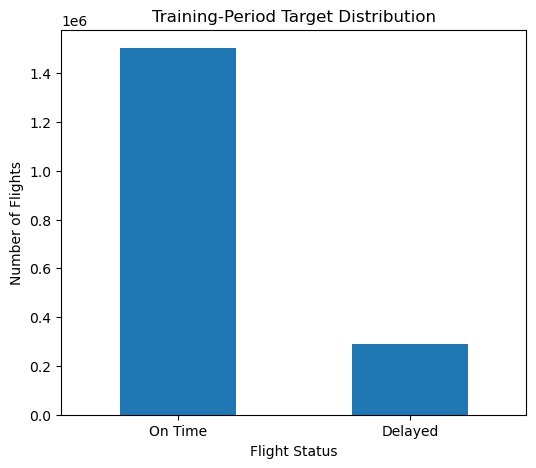

In [7]:
plt.figure(figsize=(6, 5))

class_counts.plot(kind="bar")

plt.title("Training-Period Target Distribution")
plt.xlabel("Flight Status")
plt.ylabel("Number of Flights")

plt.xticks(
    [0, 1],
    ["On Time", "Delayed"],
    rotation=0
)

plt.show()

### Interpretation

The training data is moderately imbalanced, with on-time flights forming the majority class.

The delayed class still contains a substantial number of observations. Therefore, the project will initially avoid resampling and will evaluate class-sensitive metrics such as precision, recall, F1-score, and ROC-AUC. Class weighting may be evaluated where supported by the algorithm.

In [8]:
df.columns.tolist()

['FL_DATE',
 'AIRLINE',
 'AIRLINE_DOT',
 'AIRLINE_CODE',
 'DOT_CODE',
 'FL_NUMBER',
 'ORIGIN',
 'ORIGIN_CITY',
 'DEST',
 'DEST_CITY',
 'CRS_DEP_TIME',
 'DEP_TIME',
 'DEP_DELAY',
 'CRS_ARR_TIME',
 'CRS_ELAPSED_TIME',
 'DISTANCE',
 'IS_DELAYED',
 'YEAR',
 'MONTH',
 'DAY',
 'DAY_OF_WEEK',
 'QUARTER',
 'IS_WEEKEND',
 'DEP_HOUR',
 'TIME_OF_DAY',
 'SEASON',
 'DISTANCE_CATEGORY',
 'ROUTE',
 'IS_PEAK_SEASON',
 'IS_BUSY_HOUR']

# Feature Selection

The engineered dataset contains a mixture of operational, temporal, and categorical variables.

To build a pre-departure prediction model, only variables that would be available before a flight departs are retained.

The following variables are excluded:

- Identifier columns that do not contribute meaningful predictive information.
- Variables unavailable before departure.
- Constant columns with no variation.
- Redundant variables derived from other selected features.

In [9]:
selected_features = [

    "AIRLINE",

    "ORIGIN",
    "DEST",

    "CRS_DEP_TIME",
    "CRS_ARR_TIME",
    "CRS_ELAPSED_TIME",
    "DISTANCE",

    "YEAR",
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",
    "QUARTER",

    "DEP_HOUR",
    "TIME_OF_DAY",
    "SEASON",
    "DISTANCE_CATEGORY",

    "IS_WEEKEND",
    "IS_PEAK_SEASON",
    "IS_BUSY_HOUR"

]

target = "IS_DELAYED"

In [10]:
missing = [
    col for col in selected_features + [target]
    if col not in df.columns
]

if len(missing) == 0:
    print("All selected features are available.")
else:
    print("Missing columns:", missing)

All selected features are available.


In [11]:
model_df = df[selected_features + [target]].copy()

print(model_df.shape)

model_df.head()

(2913802, 20)


,AIRLINE,ORIGIN,DEST,CRS_DEP_TIME,CRS_ARR_TIME,CRS_ELAPSED_TIME,DISTANCE,YEAR,MONTH,DAY,DAY_OF_WEEK,QUARTER,DEP_HOUR,TIME_OF_DAY,SEASON,DISTANCE_CATEGORY,IS_WEEKEND,IS_PEAK_SEASON,IS_BUSY_HOUR,IS_DELAYED
0,United Air Lines Inc.,FLL,EWR,1155,1501,186.0,1065.0,2019,1,9,Wednesday,1,11,Morning,Winter,Medium,0,0,0,0
1,Delta Air Lines Inc.,MSP,SEA,2120,2315,235.0,1399.0,2022,11,19,Saturday,4,21,Night,Autumn,Medium,1,1,0,0
2,United Air Lines Inc.,DEN,MSP,954,1252,118.0,680.0,2022,7,22,Friday,3,9,Morning,Summer,Medium,0,1,1,0
3,Delta Air Lines Inc.,MSP,SFO,1609,1829,260.0,1589.0,2023,3,6,Monday,1,16,Afternoon,Spring,Long,0,0,1,1
4,Spirit Air Lines,MCO,DFW,1840,2041,181.0,985.0,2020,2,23,Sunday,1,18,Evening,Winter,Medium,1,0,1,0


# Separate Features and Target

The selected predictor variables are separated from the target variable before splitting the dataset.

- **Features (X):** Predictor variables available before departure.
- **Target (y):** Whether the flight arrived more than 15 minutes late.

In [12]:
X = model_df.drop(columns=target)

y = model_df[target]

print("Features shape :", X.shape)
print("Target shape   :", y.shape)

Features shape : (2913802, 19)
Target shape   : (2913802,)


# Chronological Train-Validation-Test Split

Because this dataset contains flights from multiple years, a chronological split is used instead of a random split. This better represents deployment, where historical data is used to predict later flights.

The periods are:

- Training: 2019–2021
- Validation: 2022
- Temporal holdout test: January–August 2023

The 2023 holdout is not used for model fitting, hyperparameter tuning, threshold selection, or model comparison. It will be scored by the frozen final pipeline in Notebook 9.

In [13]:
train_df = df[df["YEAR"] <= 2021].copy()

validation_df = df[df["YEAR"] == 2022].copy()

test_df = df[df["YEAR"] == 2023].copy()

print("Training:", train_df.shape)
print("Validation:", validation_df.shape)
print("Testing:", test_df.shape)

Training: (1791628, 30)
Validation: (667761, 30)
Testing: (454413, 30)


In [14]:
X_train = train_df[selected_features]

y_train = train_df[target]

X_validation = validation_df[selected_features]

y_validation = validation_df[target]

X_test = test_df[selected_features]

y_test = test_df[target]

In [15]:
print("Training Features :", X_train.shape)
print("Validation Features:", X_validation.shape)
print("Testing Features  :", X_test.shape)

Training Features : (1791628, 19)
Validation Features: (667761, 19)
Testing Features  : (454413, 19)


# Data Preprocessing

The preprocessing pipeline applies different transformations according to feature type:

- Numerical features are standardized using `StandardScaler`.
- Low-cardinality categorical features are encoded using `OneHotEncoder`.
- High-cardinality categorical features are encoded using `TargetEncoder`.
- Unknown one-hot categories are handled safely during validation, testing, and deployment.

All transformations are placed inside a `ColumnTransformer` and later combined with each model in a scikit-learn `Pipeline`. This ensures that encoders and scalers are fitted only on training data.

In [16]:
numerical_features = [

    "CRS_DEP_TIME",
    "CRS_ARR_TIME",
    "CRS_ELAPSED_TIME",
    "DISTANCE",

    "YEAR",
    "MONTH",
    "DAY",
    "QUARTER",

    "DEP_HOUR",

    "IS_WEEKEND",
    "IS_PEAK_SEASON",
    "IS_BUSY_HOUR"

]

In [17]:
one_hot_features = [
    "DAY_OF_WEEK",
    "TIME_OF_DAY",
    "SEASON",
    "DISTANCE_CATEGORY"
]

target_encode_features = [
    "AIRLINE",
    "ORIGIN",
    "DEST"
]

In [18]:
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

In [19]:
one_hot_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [20]:
target_transformer = Pipeline(
    steps=[
        (
            "target_encoder",
            TargetEncoder(
                target_type="binary",
                smooth="auto",
                cv=5,
                random_state=42
            )
        )
    ]
)

In [21]:
preprocessor = ColumnTransformer(
    transformers=[

        (
            "num",
            numeric_transformer,
            numerical_features
        ),

        (
            "onehot",
            one_hot_transformer,
            one_hot_features
        ),

        (
            "target",
            target_transformer,
            target_encode_features
        )

    ],
    remainder="drop"
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('onehot', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featur